# Harmonizing Indian district names across census decades

Linking Indian health data over time runs into a basic problem: district names keep
changing. To track disease surveillance, vaccination coverage, or NFHS survey indicators
across years, you join records on district name. But districts have been renamed, split, and
respelled across census decades (1951 to 2001). "Vizagapatnam" became "Visakhapatnam",
"Bombay" became "Mumbai", and many districts were carved into new units.

A plain string join drops every record whose name drifted. This notebook matches messy
district names against a canonical list, then uses the label-free assessor to compare two
real backends on this data.

The district mapping table ships with Alethia, so everything here runs offline.

In [1]:
import pandas as pd
from importlib.resources import files

from alethia import alethia, assess_models

mapping = pd.read_csv(files("alethia.data") / "India_district_mappings.csv")
references = sorted(mapping["2001"].dropna().str.strip().unique())
print(f"{len(references)} canonical (2001) district names")
references[:8]

580 canonical (2001) district names


['Adilabad',
 'Agra',
 'Ahmadnager',
 'Ahmedabad',
 'Aizawl',
 'Ajmer',
 'Akola',
 'Aligarh']

## The messy inputs

Historical names and colonial-era spellings that a legacy dataset might carry.

In [2]:
dirty = [
    "Vizagapatnam", "Bombay", "Calcutta", "Trivandrum", "Cochin",
    "Mysore", "Poona", "Gurgaon", "Allahabad", "Pondicherry",
]
len(dirty)

10

## Matching with a sentence-transformer

Pass a model by name. Alethia embeds the queries and references and maps each query to its
nearest canonical district by cosine similarity.

In [3]:
result = alethia(dirty, references, model="all-MiniLM-L6-v2")
result[["given_entity", "alethia_prediction", "alethia_score"]]

,given_entity,alethia_prediction,alethia_score
0,Vizagapatnam,Vizianagaram,0.729009
1,Bombay,Mumbai,0.804319
2,Calcutta,Calcutta,1.000000
3,Trivandrum,Triuvannamalai Sam-,0.499973
4,Cochin,Ernakulam,0.630008
5,Mysore,Mysore,1.000000
6,Poona,Poona,1.000000
7,Gurgaon,Gurgaon,1.000000
8,Allahabad,Allahabad,1.000000
9,Pondicherry,Pondicherry,1.000000


## A string-similarity baseline

With no embedding model, Alethia falls back to RapidFuzz. It catches typos but misses
semantic renames where the new name shares little surface form.

In [4]:
fuzzy = alethia(dirty, references, model="rapidfuzz")
fuzzy[["given_entity", "alethia_prediction", "alethia_score"]]

,given_entity,alethia_prediction,alethia_score
0,Vizagapatnam,Visakhapatnam,0.800000
1,Bombay,Korba,0.545455
2,Calcutta,Calcutta,1.000000
3,Trivandrum,Thiruvarur,0.600000
4,Cochin,Bhind,0.545455
5,Mysore,Mysore,1.000000
6,Poona,Poona,1.000000
7,Gurgaon,Gurgaon,1.000000
8,Allahabad,Allahabad,1.000000
9,Pondicherry,Pondicherry,1.000000


## Which backend should you trust?

You rarely have ground-truth mappings for your own data, so you cannot just measure accuracy.
The assessor scores each model on geometric signals that need no labels: how well it
separates distinct references, how close it keeps synthesized typo variants to their source,
and how confident its top match is.

Here we compare two real sentence-transformers.

In [5]:
report = assess_models(
    queries=dirty,
    references=references,
    models={
        "MiniLM": "all-MiniLM-L6-v2",
        "mpnet": "all-mpnet-base-v2",
    },
)
report.to_table()[["model", "score", "alignment_loss", "mean_margin", "mutual_nn_rate"]]

,model,score,alignment_loss,mean_margin,mutual_nn_rate
0,MiniLM,4.25,0.756709,0.229591,1.0
1,mpnet,-4.25,0.726514,0.207568,1.0


In [6]:
print("Recommended model for this data:", report.best.name)

Recommended model for this data: MiniLM


## Visualizing the embedding space

It helps to see how the model arranges the references. We take the districts of a few states,
project their embeddings to two dimensions with UMAP, and colour by state. Districts from the
same state share naming conventions and language, so a model that captures that should place
them together. `do_pca` is the linear alternative when you want explained-variance axes.

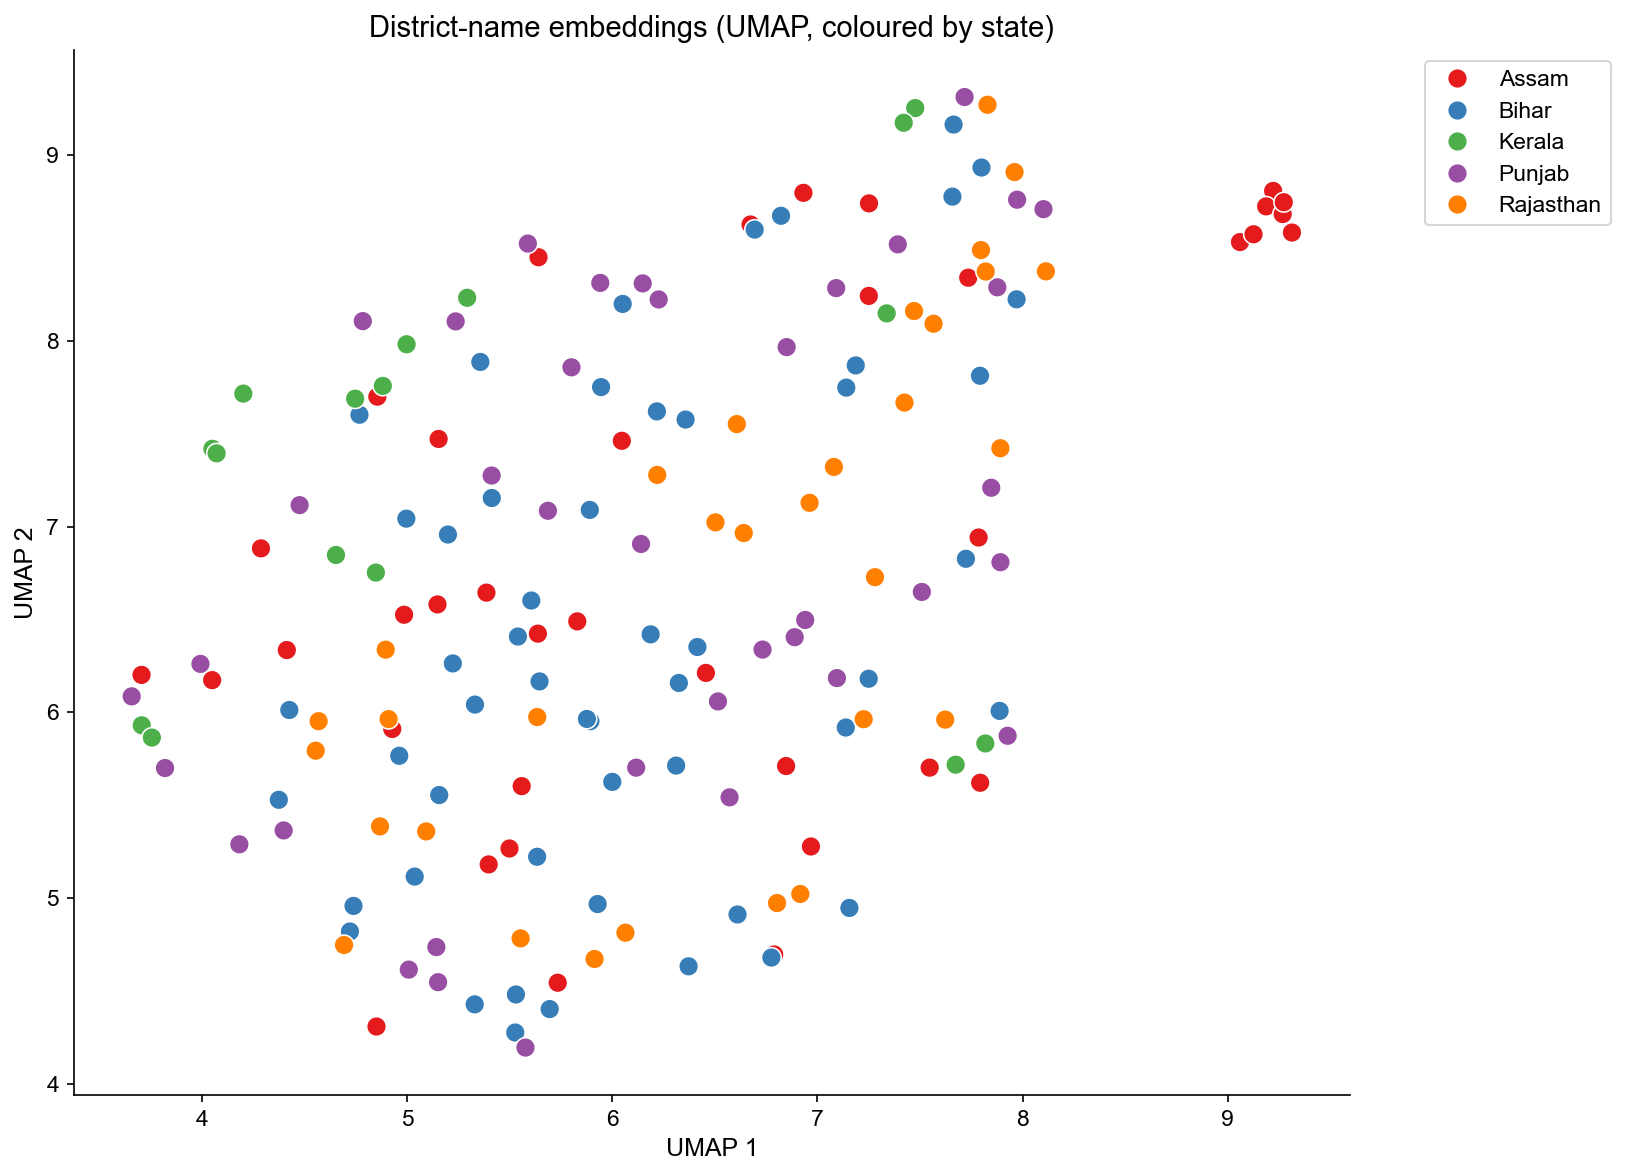

In [7]:
import matplotlib.pyplot as plt
from alethia import as_embedder, do_umap, plot_embedding, setup_matplotlib

setup_matplotlib()  # Arial, crisp DPI, legible default sizes

states = ["Kerala", "Bihar", "Rajasthan", "Punjab", "Assam"]
by_state = mapping[["State", "2001"]].dropna().drop_duplicates("2001")
by_state = by_state[by_state["State"].isin(states)]

emb = as_embedder("all-MiniLM-L6-v2").encode(by_state["2001"].tolist())
coords = do_umap(emb, n_components=2)

plt.figure(figsize=(11, 8))
plot_embedding(
    coords,
    labels=by_state["State"].tolist(),
    axis_labels=("UMAP 1", "UMAP 2"),
    title="District-name embeddings (UMAP, coloured by state)",
    point_size=90,
)

## A shareable report

`report.to_html()` writes one self-contained HTML file with the verdict, the ranking chart,
the alignment-uniformity plot, and the full metric table.

In [8]:
html = report.to_html()
print(f"Generated a {len(html) // 1024} KB self-contained report")
# report.to_html(path="district_assessment.html")  # to save it

Generated a 75 KB self-contained report


## Takeaways

- Harmonizing district names is a prerequisite for longitudinal Indian health-data linkage.
  A plain string join silently drops renamed and respelled districts.
- An embedding model resolves both typos and semantic renames; the RapidFuzz baseline only
  catches surface-level typos.
- The assessor compares real models on your data without ground truth. The next notebook
  checks that its verdicts actually match measured accuracy.
- do_pca / do_umap with plot_embedding let you see how a model arranges the
  reference names before you rely on it.